# 2 序列模型

## 2.1 理论计算题

给定序列 $S = \text{"ababc"}$，词表 $V = \{a, b, c\}$，$|V| = 3$。使用一阶马尔可夫模型 $p(x_t \mid x_{t-1})$ 与拉普拉斯平滑（加一平滑）：

$$p(x_t \mid x_{t-1}) = \frac{\text{count}(x_{t-1}, x_t) + 1}{\text{count}(x_{t-1}) + |V|}$$

其中 $\text{count}(x_{t-1})$ 为字符 $x_{t-1}$ 作为前缀出现的次数（即以其开头的转移总数）。

**转移统计（序列 ababc）：**

| 转移 | 次数 |
|:---:|:---:|
| $a \to b$ | 2 |
| $b \to a$ | 1 |
| $b \to c$ | 1 |

前缀计数：$\text{count}(a) = 2$，$\text{count}(b) = 2$。

**1. 计算 $p(a \mid b)$：**

$$p(a \mid b) = \frac{\text{count}(b, a) + 1}{\text{count}(b) + |V|} = \frac{1 + 1}{2 + 3} = \frac{2}{5} = 0.4$$

**2. 计算 $p(c \mid b)$：**

$$p(c \mid b) = \frac{\text{count}(b, c) + 1}{\text{count}(b) + |V|} = \frac{1 + 1}{2 + 3} = \frac{2}{5} = 0.4$$

（同理，未观测到的转移 $p(b \mid b) = \frac{0+1}{2+3} = 0.2$。）

## 2.2 编程题

实现文本预处理函数 `preprocess_text(text, n)`：小写化、去标点、分词、按词频构建词表、滑动窗口生成特征与标签。

C:\Users\zy254\AppData\Local\Temp\ipykernel_18740\4093349973.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


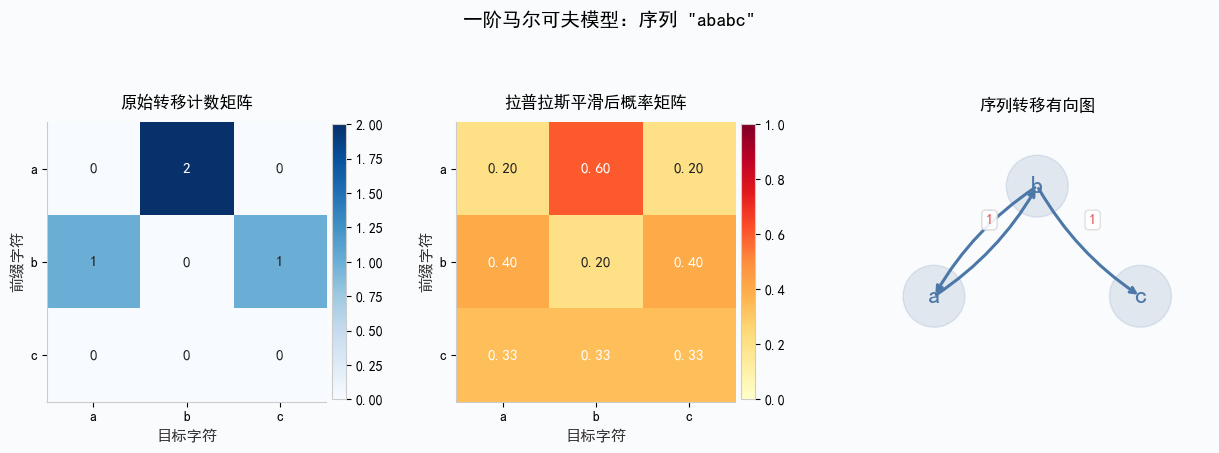

p(a|b) = 0.4000,  p(c|b) = 0.4000


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from collections import Counter
import re

matplotlib.rcParams.update({
    'font.sans-serif': ['SimHei', 'Microsoft YaHei', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'mathtext.fontset': 'stix',
    'figure.facecolor': '#FAFBFC',
    'axes.facecolor': '#FFFFFF',
    'axes.edgecolor': '#CCCCCC',
    'axes.labelcolor': '#333333',
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
})

PALETTE = ['#4C78A8', '#F58518', '#E45756', '#72B7B2', '#54A24B', '#B279A2']

def style_axes(ax, title=None):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if title:
        ax.set_title(title, pad=10)

def annotate_heatmap(ax, data, fmt_int=False, decimals=2):
    vmax = np.max(data) if np.max(data) > 0 else 1
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            txt = f'{int(val)}' if fmt_int else f'{val:.{decimals}f}'
            color = 'white' if val > 0.55 * vmax else '#222222'
            ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=11, fontweight='bold')

def polish_bar_ax(ax):
    ax.yaxis.grid(True, alpha=0.35, linestyle='--')
    ax.set_axisbelow(True)

def polish_line_ax(ax):
    ax.grid(True, alpha=0.35, linestyle='--')
    ax.set_axisbelow(True)

# ---- 2.1 可视化：转移计数与概率矩阵 ----
vocab_chars = ['a', 'b', 'c']
seq = 'ababc'
transitions = [(seq[i], seq[i+1]) for i in range(len(seq)-1)]
trans_count = Counter(transitions)
prefix_count = Counter(t[0] for t in transitions)
V_size = 3

count_mat = np.zeros((3, 3))
prob_mat = np.zeros((3, 3))
for i, src in enumerate(vocab_chars):
    for j, dst in enumerate(vocab_chars):
        count_mat[i, j] = trans_count.get((src, dst), 0)
        prob_mat[i, j] = (trans_count.get((src, dst), 0) + 1) / (prefix_count.get(src, 0) + V_size)

fig = plt.figure(figsize=(15, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.15], wspace=0.35)
ax0, ax1, ax2 = [fig.add_subplot(gs[0, i]) for i in range(3)]

im0 = ax0.imshow(count_mat, cmap='Blues', vmin=0)
ax0.set_xticks(range(3)); ax0.set_yticks(range(3))
ax0.set_xticklabels(vocab_chars); ax0.set_yticklabels(vocab_chars)
ax0.set_xlabel('目标字符'); ax0.set_ylabel('前缀字符')
style_axes(ax0, '原始转移计数矩阵')
annotate_heatmap(ax0, count_mat, fmt_int=True)
plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02)

im1 = ax1.imshow(prob_mat, cmap='YlOrRd', vmin=0, vmax=1)
ax1.set_xticks(range(3)); ax1.set_yticks(range(3))
ax1.set_xticklabels(vocab_chars); ax1.set_yticklabels(vocab_chars)
ax1.set_xlabel('目标字符'); ax1.set_ylabel('前缀字符')
style_axes(ax1, '拉普拉斯平滑后概率矩阵')
annotate_heatmap(ax1, prob_mat, decimals=2)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02)

pos = {'a': (0.2, 0.5), 'b': (0.5, 0.82), 'c': (0.8, 0.5)}
for (src, dst), w in trans_count.items():
    x0, y0 = pos[src]; x1, y1 = pos[dst]
    ax2.annotate('', xy=(x1, y1), xytext=(x0, y0),
                 arrowprops=dict(arrowstyle='->', color='#4C78A8', lw=2.2,
                                 connectionstyle='arc3,rad=0.12'))
    mx, my = (x0 + x1) / 2, (y0 + y1) / 2 + 0.05
    ax2.text(mx, my, str(w), fontsize=11, color='#E45756', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#DDDDDD', alpha=0.9))
for ch, (x, y) in pos.items():
    circle = plt.Circle((x, y), 0.09, color=PALETTE[0], alpha=0.15, zorder=1)
    ax2.add_patch(circle)
    ax2.text(x, y, ch, ha='center', va='center', fontsize=18, fontweight='bold', color=PALETTE[0])
ax2.set_xlim(0, 1); ax2.set_ylim(0.2, 1)
style_axes(ax2, '序列转移有向图')
ax2.set_aspect('equal'); ax2.axis('off')

fig.suptitle('一阶马尔可夫模型：序列 "ababc"', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'p(a|b) = {prob_mat[1, 0]:.4f},  p(c|b) = {prob_mat[1, 2]:.4f}')


词表: {'machine': 0, 'the': 1, 'time': 2}
特征: [['the', 'time'], ['time', 'machine']]
标签: ['machine', None]


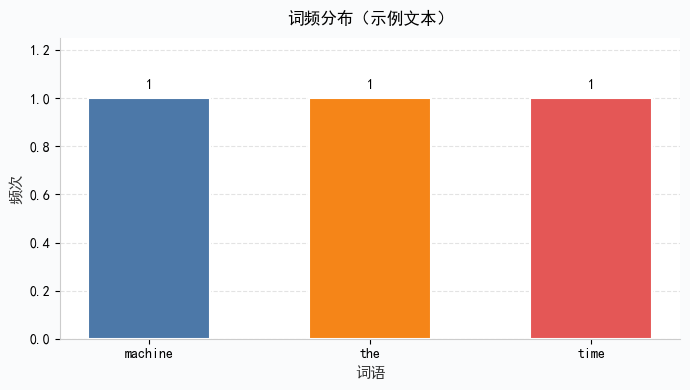

In [20]:
def preprocess_text(text, n):
    """
    文本预处理：规范化、分词、构建词表、滑动窗口生成特征与标签。
    :param text: 输入文本
    :param n: 滑动窗口长度
    :return: (vocab_dict, (feature_list, label_list))
    """
    # 1. 小写化并去除标点，仅保留字母和空格
    normalized = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    normalized = re.sub(r'\s+', ' ', normalized).strip()
    
    # 2. 按空格分词
    tokens = normalized.split() if normalized else []
    
    # 3. 按词频降序构建词表（同频按字母序）
    freq = Counter(tokens)
    sorted_words = sorted(freq.keys(), key=lambda w: (-freq[w], w))
    vocab_dict = {word: idx for idx, word in enumerate(sorted_words)}
    
    # 4. 滑动窗口生成特征与标签
    feature_list, label_list = [], []
    for i in range(len(tokens) - n + 1):
        window = tokens[i:i + n]
        label = tokens[i + n] if i + n < len(tokens) else None
        feature_list.append(window)
        label_list.append(label)
    
    return vocab_dict, (feature_list, label_list)


# 测试代码
text = 'The time machine'
n = 2
vocab, (features, labels) = preprocess_text(text, n)
print('词表:', vocab)
print('特征:', features)
print('标签:', labels)


# 可视化：词频柱状图
tokens_demo = re.sub(r'[^a-zA-Z\s]', '', text.lower()).split()
freq_demo = Counter(tokens_demo)
words = list(vocab.keys())
freqs = [freq_demo[w] for w in words]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(words))]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(words, freqs, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
ax.set_xlabel('词语'); ax.set_ylabel('频次')
style_axes(ax, '词频分布（示例文本）')
polish_bar_ax(ax)
ax.set_ylim(0, max(freqs) * 1.25 if freqs else 1)
for bar, f in zip(bars, freqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, str(f),
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


# 3 循环神经网络

## 3.1 理论计算题

考虑无偏置的线性 RNN：

$$h_t = W_{hh} h_{t-1} + W_{hx} x_t, \quad o_t = W_{oh} h_t, \quad L = \frac{1}{2} \sum_{t=1}^{T} (o_t - y_t)^2$$

**1. 利用 BPTT 推导 $\frac{\partial L}{\partial W_{hh}}$：**

定义误差信号 $\delta_t^h = \frac{\partial L}{\partial h_t}$。由链式法则：

$$\delta_t^h = W_{oh}^\top (o_t - y_t) + W_{hh}^\top \delta_{t+1}^h, \quad \delta_T^h = W_{oh}^\top (o_T - y_T)$$

由于 $h_t = W_{hh} h_{t-1} + W_{hx} x_t$，有 $\frac{\partial h_t}{\partial W_{hh}} = h_{t-1}^\top$（外积形式），故：

$$\boxed{\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \delta_t^h \, h_{t-1}^\top}$$

展开到所有时间步，$\delta_t^h$ 可进一步递归展开为：

$$\delta_t^h = \sum_{k=t}^{T} (W_{hh}^\top)^{k-t} W_{oh}^\top (o_k - y_k)$$

因此：

$$\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^{T} \left[\sum_{k=t}^{T} (W_{hh}^\top)^{k-t} W_{oh}^\top (o_k - y_k)\right] h_{t-1}^\top$$

**2. 梯度消失与爆炸的条件：**

从 $\delta_t^h$ 的展开式可见，梯度沿时间反向传播时反复乘以 $W_{hh}^\top$。设 $W_{hh}$ 的最大奇异值为 $\sigma_{\max}$：

- 若 $\sigma_{\max}(W_{hh}) < 1$：$(W_{hh}^\top)^{k-t}$ 随 $(k-t)$ 增大而衰减 → **梯度消失**，长程依赖难以学习。
- 若 $\sigma_{\max}(W_{hh}) > 1$：幂次项指数增长 → **梯度爆炸**，训练不稳定。
- 若 $\sigma_{\max}(W_{hh}) \approx 1$：梯度可较好地在时间步间传递。

## 3.2 编程题

实现简单 RNN 单元的前向传播与单步反向传播（仅计算梯度，不更新权重）。

h_t shape: (2, 3)
梯度形状: {'dx_t': (2, 4), 'dh_prev': (2, 3), 'dW_hx': (4, 3), 'dW_hh': (3, 3), 'db_h': (3,)}


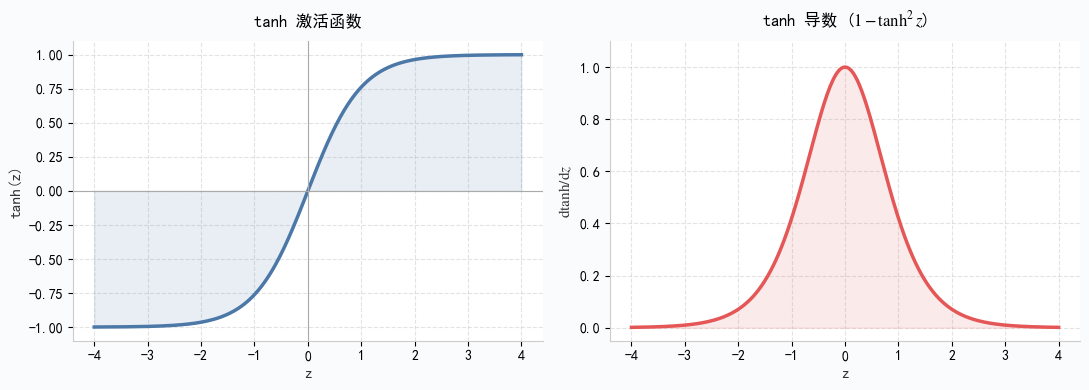

In [21]:
import numpy as np

def rnn_step_forward(x_t, h_prev, W_hx, W_hh, b_h):
    """
    RNN 单步前向传播
    :param x_t: (batch_size, input_size)
    :param h_prev: (batch_size, hidden_size)
    :param W_hx: (input_size, hidden_size)
    :param W_hh: (hidden_size, hidden_size)
    :param b_h: (hidden_size,)
    :return: h_t
    """
    z_t = x_t @ W_hx + h_prev @ W_hh + b_h
    h_t = np.tanh(z_t)
    cache = (x_t, h_prev, W_hx, W_hh, z_t, h_t)
    return h_t, cache


def rnn_step_backward(dh_next, cache):
    """
    RNN 单步反向传播
    :param dh_next: (batch_size, hidden_size) 上游梯度
    :return: dx_t, dh_prev, dW_hx, dW_hh, db_h
    """
    x_t, h_prev, W_hx, W_hh, z_t, h_t = cache
    
    # tanh 的导数: 1 - tanh^2(z)
    dz_t = dh_next * (1 - h_t ** 2)
    
    dW_hx = x_t.T @ dz_t
    dW_hh = h_prev.T @ dz_t
    db_h = np.sum(dz_t, axis=0)
    dx_t = dz_t @ W_hx.T
    dh_prev = dz_t @ W_hh.T
    
    return dx_t, dh_prev, dW_hx, dW_hh, db_h


# 测试代码
np.random.seed(42)
batch_size, input_size, hidden_size = 2, 4, 3
x_t = np.random.randn(batch_size, input_size)
h_prev = np.random.randn(batch_size, hidden_size)
W_hx = np.random.randn(input_size, hidden_size) * 0.1
W_hh = np.random.randn(hidden_size, hidden_size) * 0.1
b_h = np.zeros(hidden_size)

h_t, cache = rnn_step_forward(x_t, h_prev, W_hx, W_hh, b_h)
dh_next = np.random.randn(batch_size, hidden_size)
grads = rnn_step_backward(dh_next, cache)
print('h_t shape:', h_t.shape)
print('梯度形状:', {k: v.shape for k, v in zip(
    ['dx_t', 'dh_prev', 'dW_hx', 'dW_hh', 'db_h'], grads)})


# 可视化：tanh 激活与导数
z = np.linspace(-4, 4, 300)
tanh_z = np.tanh(z)
dtanh_z = 1 - tanh_z ** 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(z, tanh_z, color=PALETTE[0], lw=2.5)
axes[0].fill_between(z, tanh_z, 0, color=PALETTE[0], alpha=0.12)
axes[0].axhline(0, color='#AAAAAA', lw=0.8); axes[0].axvline(0, color='#AAAAAA', lw=0.8)
style_axes(axes[0], 'tanh 激活函数')
polish_line_ax(axes[0])
axes[0].set_xlabel('z'); axes[0].set_ylabel('tanh(z)')
axes[0].set_ylim(-1.1, 1.1)

axes[1].plot(z, dtanh_z, color=PALETTE[2], lw=2.5)
axes[1].fill_between(z, dtanh_z, 0, color=PALETTE[2], alpha=0.12)
style_axes(axes[1], r'tanh 导数 ($1 - \tanh^2 z$)')
polish_line_ax(axes[1])
axes[1].set_xlabel('z'); axes[1].set_ylabel(r'$\mathrm{d}\tanh / \mathrm{d}z$')
axes[1].set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()


# 4 高级循环神经网络

## 4.1 理论计算题

深度双向 RNN：$L$ 层，每层隐藏单元数 $H$，输入维度 $D$，输出维度 $O$（仅考虑最终输出层）。

**逐层参数量分析（含偏置）：**

| 层 | 每方向参数量 | 双向参数量 |
|:---:|:---:|:---:|
| 第 1 层 | $H \cdot D + H \cdot H + H$ | $2H(D + H + 1)$ |
| 第 $l$ 层 ($l \ge 2$) | $H \cdot 2H + H \cdot H + H = H(3H+1)$ | $2H(3H+1)$ |
| 输出层 | — | $O \cdot 2H + O = O(2H+1)$ |

第 $l \ge 2$ 层输入为前一层双向拼接后的 $2H$ 维向量。

**总参数量：**

$$\boxed{N_{\text{params}} = 2H(D + H + 1) + 2(L-1)H(3H+1) + O(2H+1)}$$

等价写法：$N_{\text{params}} = 2H\big[(D+H+1) + (L-1)(3H+1)\big] + O(2H+1)$

## 4.2 编程题

实现双向 RNN 编码器，返回每个时间步拼接的隐藏状态及最终序列表示。

每步隐藏状态形状: torch.Size([5, 3, 32])
序列表示形状: torch.Size([3, 32])


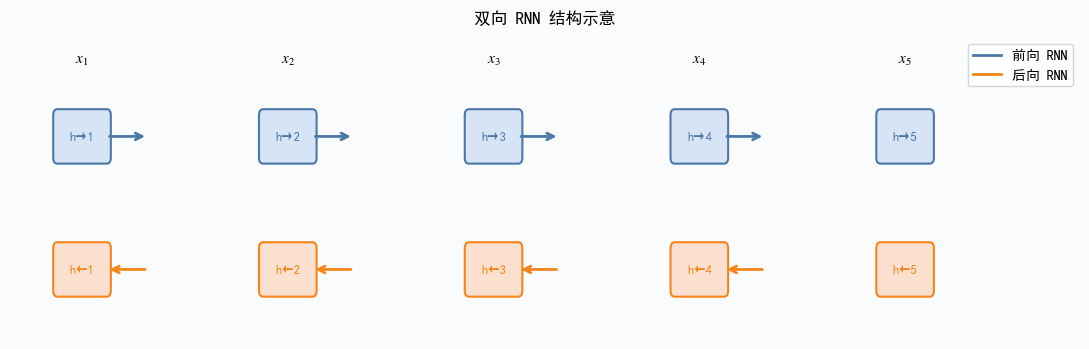

In [22]:
import torch
import torch.nn as nn

class BiRNNEncoder(nn.Module):
    """双向 RNN 编码器"""
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=False  # 输入形状 (seq_len, batch, input_dim)
        )
        self.hidden_dim = hidden_dim

    def forward(self, X):
        """
        :param X: (seq_len, batch, input_dim)
        :return: all_hidden (seq_len, batch, 2*hidden_dim), final_repr (batch, 2*hidden_dim)
        """
        output, _ = self.rnn(X)
        # output: (seq_len, batch, 2*hidden_dim) — 每步拼接前向与后向
        # 最终时间步的拼接隐藏状态作为序列表示
        final_repr = output[-1]  # (batch, 2*hidden_dim)
        return output, final_repr


# 测试代码
seq_len, batch, input_dim, hidden_dim = 5, 3, 8, 16
encoder = BiRNNEncoder(input_dim, hidden_dim, num_layers=2)
X = torch.randn(seq_len, batch, input_dim)
all_hidden, final_repr = encoder(X)
print('每步隐藏状态形状:', all_hidden.shape)
print('序列表示形状:', final_repr.shape)


# 可视化：双向 RNN 架构示意
fig, ax = plt.subplots(figsize=(11, 3.6))
T = 5
y_fwd, y_bwd = 0.72, 0.28
for t in range(T):
    x = t + 0.55
    ax.add_patch(FancyBboxPatch((x-0.12, y_fwd-0.07), 0.24, 0.14, boxstyle='round,pad=0.02',
                                facecolor='#D6E4F5', edgecolor=PALETTE[0], linewidth=1.5))
    ax.add_patch(FancyBboxPatch((x-0.12, y_bwd-0.07), 0.24, 0.14, boxstyle='round,pad=0.02',
                                facecolor='#FBE0D0', edgecolor=PALETTE[1], linewidth=1.5))
    ax.text(x, y_fwd, f'h→{t+1}', ha='center', va='center', fontsize=9, color=PALETTE[0])
    ax.text(x, y_bwd, f'h←{t+1}', ha='center', va='center', fontsize=9, color=PALETTE[1])
    ax.text(x, 0.97, f'$x_{t+1}$', ha='center', va='center', fontsize=11)
    if t < T - 1:
        ax.add_patch(FancyArrowPatch((x+0.12, y_fwd), (x+0.32, y_fwd), arrowstyle='->',
                                     mutation_scale=12, color=PALETTE[0], lw=2))
        ax.add_patch(FancyArrowPatch((x+0.32, y_bwd), (x+0.12, y_bwd), arrowstyle='->',
                                     mutation_scale=12, color=PALETTE[1], lw=2))
ax.plot([], [], color=PALETTE[0], lw=2, label='前向 RNN')
ax.plot([], [], color=PALETTE[1], lw=2, label='后向 RNN')
ax.legend(loc='upper right', frameon=True, fancybox=True)
ax.set_xlim(0.2, T+0.4); ax.set_ylim(0.05, 1.05)
style_axes(ax, '双向 RNN 结构示意')
ax.axis('off')
plt.tight_layout()
plt.show()


# 5 嵌入向量

## 5.1 理论计算题

Skip-gram 模型 + 负采样（Negative Sampling），中心词 $w_c$，上下文词 $w_o$，负样本数 $K$。

**目标函数（最大化对数似然，等价于最小化以下损失）：**

$$\mathcal{L} = -\log \sigma(\mathbf{u}_o^\top \mathbf{v}_c) - \sum_{k=1}^{K} \log \sigma(-\mathbf{u}_{n_k}^\top \mathbf{v}_c)$$

其中 $\sigma(x) = \frac{1}{1+e^{-x}}$ 为 sigmoid 函数，$\mathbf{v}_c$ 为中心词向量，$\mathbf{u}_o$ 为上下文词输出向量，$\mathbf{u}_{n_k}$ 为第 $k$ 个负样本的输出向量。

**负样本采样方式：**

负样本 $n_k$ 从噪声分布 $P_n(w)$ 中独立采样。常用做法是基于词频的平滑分布：

$$P_n(w) = \frac{U(w)^{3/4}}{\sum_{w'} U(w')^{3/4}}$$

其中 $U(w)$ 为词 $w$ 在语料中的出现频次。指数 $3/4$ 可缓解高频词被过度采样的问题，使低频词获得更多训练机会。

## 5.2 编程题

实现 CBOW 模型的前向传播与交叉熵损失（完整 softmax，不使用负采样）。

CBOW Loss: 1.9323


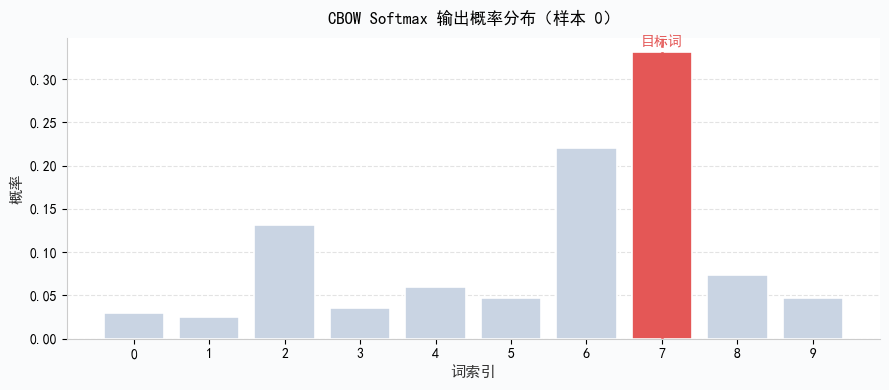

In [23]:
import torch
import torch.nn.functional as F

def cbow_forward(context_indices, target_index, W, W_out, V, d):
    """
    CBOW 前向传播与损失计算
    :param context_indices: list of list, 每个样本的上下文词索引
    :param target_index: list, 中心词索引
    :param W: (V, d) 输入嵌入矩阵
    :param W_out: (d, V) 输出权重矩阵
    :param V: 词表大小
    :param d: 嵌入维度
    :return: loss (标量)
    """
    context_tensor = torch.tensor(context_indices, dtype=torch.long)  # (batch, context_size)
    target_tensor = torch.tensor(target_index, dtype=torch.long)       # (batch,)
    
    # 1. 取上下文词向量并求平均作为隐藏层
    context_embeds = W[context_tensor]           # (batch, context_size, d)
    hidden = context_embeds.mean(dim=1)          # (batch, d)
    
    # 2. 完整 softmax 输出概率分布
    logits = hidden @ W_out                      # (batch, V)
    log_probs = F.log_softmax(logits, dim=-1)
    
    # 3. 交叉熵损失
    loss = F.nll_loss(log_probs, target_tensor)
    return loss


# 测试代码
V, d = 10, 4
W = torch.randn(V, d)
W_out = torch.randn(d, V)
context_indices = [[1, 3, 5], [2, 4, 6]]
target_index = [7, 8]
loss = cbow_forward(context_indices, target_index, W, W_out, V, d)
print(f'CBOW Loss: {loss.item():.4f}')


# 可视化：单个样本的 softmax 概率分布
with torch.no_grad():
    ctx = torch.tensor([context_indices[0]], dtype=torch.long)
    hidden = W[ctx].mean(dim=1)
    probs = F.softmax(hidden @ W_out, dim=-1).squeeze().numpy()

fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE[2] if i == target_index[0] else '#C9D4E3' for i in range(V)]
bars = ax.bar(range(V), probs, color=colors, edgecolor='white', linewidth=1.2)
ax.axvline(target_index[0], color=PALETTE[2], ls='--', lw=1.8, alpha=0.8)
ax.text(target_index[0], max(probs)*1.02, '目标词', ha='center', color=PALETTE[2], fontsize=10)
ax.set_xlabel('词索引'); ax.set_ylabel('概率')
ax.set_xticks(range(V))
style_axes(ax, 'CBOW Softmax 输出概率分布（样本 0）')
polish_bar_ax(ax)
plt.tight_layout()
plt.show()


# 6 注意力机制

## 6.1 理论计算题

给定 $Q \in \mathbb{R}^{2 \times 4}$，$K \in \mathbb{R}^{3 \times 4}$，$V \in \mathbb{R}^{3 \times 5}$，$d_k = 4$。

缩放点积注意力（无 mask）：

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

**步骤 1：计算分数矩阵**

$$S = \frac{Q K^\top}{\sqrt{4}} = \frac{Q K^\top}{2} \in \mathbb{R}^{2 \times 3}$$

其中 $S_{ij} = \frac{1}{2} \sum_{l=1}^{4} Q_{il} K_{jl}$，表示第 $i$ 个 query 与第 $j$ 个 key 的相似度。

**步骤 2：对每行做 softmax**

$$A_{ij} = \frac{\exp(S_{ij})}{\sum_{j'=1}^{3} \exp(S_{ij'})}, \quad A \in \mathbb{R}^{2 \times 3}$$

每行和为 1，$A_{ij}$ 表示 query $i$ 对 key $j$ 的注意力权重。

**步骤 3：加权求和**

$$O = A V \in \mathbb{R}^{2 \times 5}, \quad O_{ik} = \sum_{j=1}^{3} A_{ij} V_{jk}$$

输出矩阵 $O$ 的每一行是 value 向量按注意力权重的加权组合。

## 6.2 编程题

实现多头注意力（Multi-Head Attention）前向传播，`num_heads=2`，`d_model=4`。

分数矩阵 S (2x3):
[[0.5 0.5 0.5]
 [0.5 0.5 0.5]]

注意力权重 A (2x3):
[[0.3333 0.3333 0.3333]
 [0.3333 0.3333 0.3333]]

输出矩阵 O (2x5):
[[0.3333 0.3333 0.3333 0.     1.    ]
 [0.3333 0.3333 0.3333 0.     1.    ]]


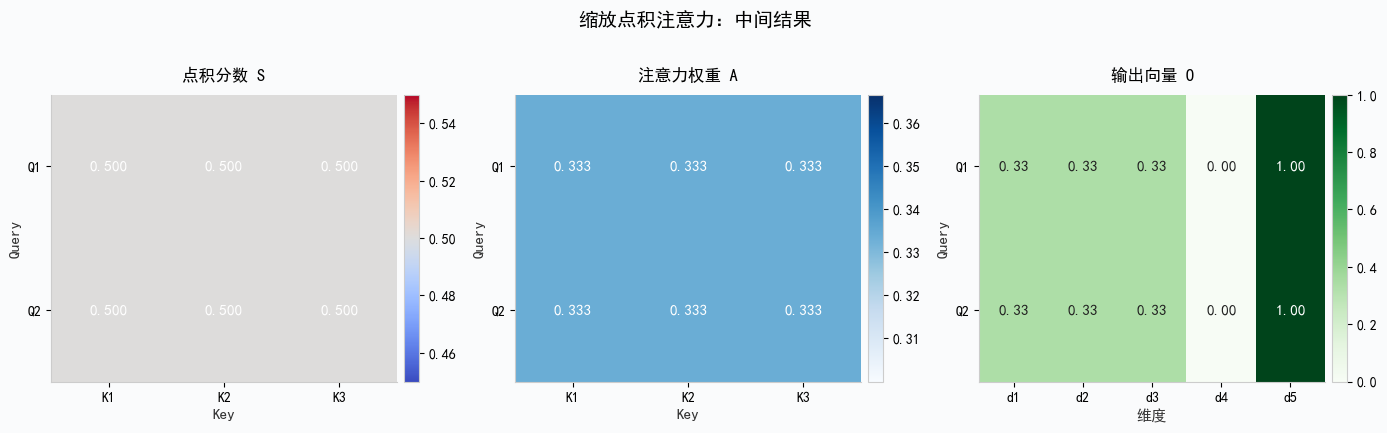


MHA 输入形状: torch.Size([3, 2, 4])
MHA 输出形状: torch.Size([3, 2, 4])
注意力权重形状: torch.Size([2, 2, 3, 3])


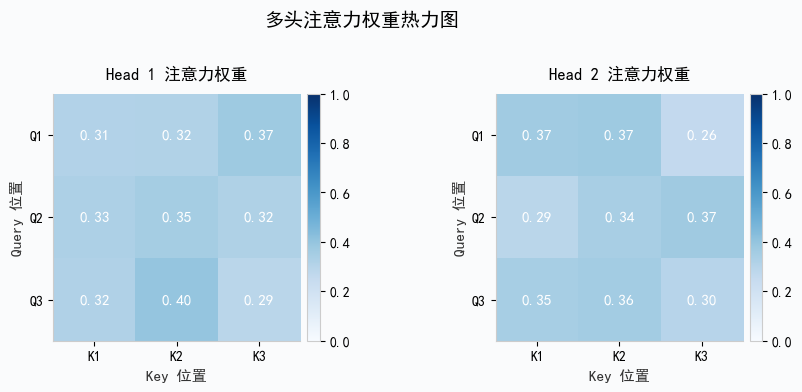

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

def scaled_dot_product_attention(Q, K, V):
    """缩放点积注意力"""
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    attn = F.softmax(scores, dim=-1)
    return attn @ V, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X):
        """
        :param X: (seq_len, batch, d_model)
        :return: (seq_len, batch, d_model)
        """
        seq_len, batch, _ = X.shape
        
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        
        def split_heads(t):
            t = t.view(seq_len, batch, self.num_heads, self.d_k)
            return t.permute(1, 2, 0, 3)
        
        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)
        out, attn = scaled_dot_product_attention(Q, K, V)
        out = out.permute(2, 0, 1, 3).contiguous().view(seq_len, batch, self.d_model)
        return self.W_o(out), attn


# ---- 6.1 数值示例与可视化 ----
Q = torch.tensor([[1., 0., 1., 0.], [0., 1., 0., 1.]])
K = torch.tensor([[1., 1., 0., 0.], [0., 1., 1., 0.], [0., 0., 1., 1.]])
V = torch.tensor([[1., 0., 0., 0., 1.], [0., 1., 0., 0., 1.], [0., 0., 1., 0., 1.]])

d_k = 4
scores = Q @ K.T / math.sqrt(d_k)
attn_weights = F.softmax(scores, dim=-1)
output = attn_weights @ V

print('分数矩阵 S (2x3):')
print(scores.numpy().round(4))
print('\n注意力权重 A (2x3):')
print(attn_weights.detach().numpy().round(4))
print('\n输出矩阵 O (2x5):')
print(output.detach().numpy().round(4))

row_labels = [f'Q{i+1}' for i in range(scores.shape[0])]
col_labels = [f'K{j+1}' for j in range(scores.shape[1])]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
titles = ['点积分数 S', '注意力权重 A', '输出向量 O']
cmaps = ['coolwarm', 'Blues', 'Greens']
mats = [scores.numpy(), attn_weights.numpy(), output.numpy()]
for ax, mat, title, cmap in zip(axes, mats, titles, cmaps):
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    ax.set_xticks(range(mat.shape[1]))
    ax.set_yticks(range(mat.shape[0]))
    if mat.shape == scores.shape:
        ax.set_xticklabels(col_labels)
        ax.set_yticklabels(row_labels)
        ax.set_xlabel('Key'); ax.set_ylabel('Query')
    elif mat.shape == output.shape:
        ax.set_xticklabels([f'd{j+1}' for j in range(mat.shape[1])])
        ax.set_yticklabels(row_labels)
        ax.set_xlabel('维度'); ax.set_ylabel('Query')
    style_axes(ax, title)
    annotate_heatmap(ax, mat, decimals=3 if mat.max() < 1 else 2)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.suptitle('缩放点积注意力：中间结果', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---- 6.2 测试 MultiHeadAttention ----
mha = MultiHeadAttention(d_model=4, num_heads=2)
seq_len, batch = 3, 2
X = torch.randn(seq_len, batch, 4)
out, attn = mha(X)
print(f'\nMHA 输入形状: {X.shape}')
print(f'MHA 输出形状: {out.shape}')
print(f'注意力权重形状: {attn.shape}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for h in range(2):
    data = attn[0, h].detach().numpy()
    im = axes[h].imshow(data, cmap='Blues', vmin=0, vmax=1)
    style_axes(axes[h], f'Head {h+1} 注意力权重')
    axes[h].set_xlabel('Key 位置'); axes[h].set_ylabel('Query 位置')
    axes[h].set_xticks(range(seq_len)); axes[h].set_yticks(range(seq_len))
    axes[h].set_xticklabels([f'K{t+1}' for t in range(seq_len)])
    axes[h].set_yticklabels([f'Q{t+1}' for t in range(seq_len)])
    annotate_heatmap(axes[h], data, decimals=2)
    plt.colorbar(im, ax=axes[h], fraction=0.046, pad=0.02)
plt.suptitle('多头注意力权重热力图', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
